# Notebook 02 — Mounting the Lens (Warping Real Images)
## From maths to actual pixels · Paper §3.1

---
### Story so far → where we are now

In **NB 01** we built the lens: the warp function $\Phi$, its inverse $\Phi^{-1}$, and the
Jacobian. But we only ever fed it lists of *coordinates*. We never touched an actual image.

**This notebook turns that maths into a real image operation.** By the end we have a
plug-and-play PyTorch layer, `FoveationWarpLayer`, that takes a photo and the lens settings
$(o, R)$ and returns the magnified photo — fully differentiable, ready to drop in front of
any detector. This is the "mount the lens onto the camera" step.

---
### The one idea you need: *inverse* warping

To build the output image, we don't ask "where does each *input* pixel go?" (that leaves
holes, like spraying paint through a stencil). Instead we go the other way and ask, for each
**output** pixel: *"which input pixel should I copy here?"*

$$\text{output}(y) = \text{input}\bigl(\underbrace{\Phi^{-1}(y)}_{\text{where to look in the original}}\bigr)$$

Every output pixel gets filled exactly once — no holes, no overlaps. This is why we spent so
much effort on the inverse $\Phi^{-1}$ in NB 01: **it is the heart of the warp.**

| Direction | Question per pixel | Problem |
|---|---|---|
| Forward (push) | where does input pixel $x$ land? | leaves gaps |
| **Inverse (pull)** ✓ | where does output pixel $y$ come from? | every pixel filled |

PyTorch has a built-in tool for exactly this "pull" operation — `grid_sample` — which we
explain next. It is also differentiable, so training gradients pass straight through the warp.

In [28]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import torch
import torch.nn as nn
import torch.nn.functional as F
import warnings
from torch import Tensor
import matplotlib.pyplot as plt
import numpy as np

torch.set_default_dtype(torch.float32)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

PyTorch 2.12.0+cu130 | device: cpu


---
### Importing from the `telescope` package

All geometric primitives live in `telescope/geometry.py`. The warp layer lives in `telescope/warp.py`.
These are real Python modules — the same code that runs in training scripts and inference pipelines.

In [29]:
from telescope.geometry import EPS, hyperbolic_inverse, hyperbolic_foveated_transform
from telescope.warp import FoveationWarpLayer, create_output_grid, compute_source_grid
from telescope.estimator import FoveationEstimator

print('telescope package imported successfully.')

telescope package imported successfully.


---
## 1 · How `grid_sample` works

`torch.nn.functional.grid_sample` is the workhorse of any differentiable image warp. Here's the mental model:

```
          Input image I              grid_sample             Output image I'
        ┌──────────────────┐                               ┌──────────────────┐
        │ (B, C, H_in, W_in)│  ←── bilinear lookup ────   │(B, C, H_out, W_out)│
        └──────────────────┘                               └──────────────────┘
                 ↑                                                  |
           sample at x                                        for each y
                 ↑                                                  |
        ┌──────────────────┐
        │  source grid     │  x = Φ⁻¹(y)
        │  (B, H, W, 2)    │
        └──────────────────┘
```

**Key facts about `grid_sample`:**
- Coordinates are **normalized**: `(-1, -1)` = top-left pixel, `(1, 1)` = bottom-right pixel
- `grid[b, h, w] = [x, y]` means: output pixel `(b, h, w)` is sampled from input at **normalized position** `(x, y)`
- `mode='bilinear'`: blends the 4 neighboring pixels by distance — smooth and differentiable
- `padding_mode='border'`: pixels outside `[-1,1]` clamp to the edge (avoids black borders)
- `align_corners=True`: corner pixels land exactly at `±1` (consistent with our `[-1,1]²` convention)

```
★ Insight ─────────────────────────────────────
  • grid_sample is differentiable w.r.t. BOTH the input image and the
    grid coordinates. This means gradients flow back from the detection
    loss through the warped image into the source coordinates.
  • The grid coordinates x = Φ⁻¹(y) were computed with NR, whose
    backward (via IFT) provides ∂x/∂y. Together: full end-to-end grad.
  • 'border' padding is critical for autonomous driving: road edges
    and sky are at the image boundary, and black borders would
    create false "empty regions" for the detector.
─────────────────────────────────────────────────
```

---
## 2 · Building the output grid

The first step is to create a regular grid of output positions — one coordinate per output pixel, covering `[-1, 1]²`.
This is the "canvas" we will fill in via inverse warping.

In [30]:
def create_output_grid(height: int, width: int, device=None) -> Tensor:
    """Uniform normalized grid covering [-1, 1]^2 for an (H, W) image.

    In plain terms: for every pixel in the output image, this gives
    its (x, y) coordinate in the normalized [-1, 1] coordinate system
    that grid_sample and our transform both use.

    Returns:
        (H, W, 2) float tensor  — [..., 0] = x (horizontal), [..., 1] = y (vertical)
    """
    # torch.linspace(-1, 1, N) gives N evenly-spaced values from -1 to 1
    xs = torch.linspace(-1.0, 1.0, width,  device=device)   # (W,)
    ys = torch.linspace(-1.0, 1.0, height, device=device)   # (H,)

    # meshgrid with indexing='ij' swaps row/col — we want 'xy' so that
    # the first dim of the output is height (rows) and second is width (cols)
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')  # (H, W) each

    return torch.stack([grid_x, grid_y], dim=-1)             # (H, W, 2)


# Quick sanity check: corners and center
g = create_output_grid(5, 5)
print(f'Grid shape : {g.shape}')
print(f'Top-left   : {g[0, 0].tolist()}   (expect [-1, -1])')
print(f'Top-right  : {g[0,-1].tolist()}   (expect [ 1, -1])')
print(f'Center     : {g[2, 2].tolist()}   (expect [ 0,  0])')
print(f'Bot-right  : {g[-1,-1].tolist()}  (expect [ 1,  1])')

Grid shape : torch.Size([5, 5, 2])
Top-left   : [-1.0, -1.0]   (expect [-1, -1])
Top-right  : [1.0, -1.0]   (expect [ 1, -1])
Center     : [0.0, 0.0]   (expect [ 0,  0])
Bot-right  : [1.0, 1.0]  (expect [ 1,  1])


---
## 3 · Computing the source grid: $x = \Phi^{-1}(y)$

For every output pixel position $y$, we ask: *"which position in the original image should I sample from?"*

The answer is $x = \Phi^{-1}(y)$. Points near the foveation center get "unpacked" from a small input region (magnification), while peripheral points are pulled from a wider input region (compression).

```
★ Insight ─────────────────────────────────────
  • We loop over batch elements (not vectorise across batch) because
    each image has its own (o, R). A loop over B=4 is negligible vs.
    the cost of NR over H×W points. The NR itself is fully vectorised
    across all H×W positions simultaneously.
  • The NR forward runs inside torch.no_grad(), so the memory cost of
    the source-grid computation is O(H×W), not O(iterations × H×W).
    Only the final x* is stored for the backward pass.
─────────────────────────────────────────────────
```

In [31]:
def compute_source_grid(
    height: int,
    width: int,
    o: Tensor,
    R: Tensor,
    alpha: float = 2.0,
    p: float = 2.0,
    device=None,
) -> Tensor:
    """For each output pixel y, compute x = Phi^{-1}(y) — where to sample in the input.

    Handles both single-image and batched calls:
        single  :  o=(2,),  R=scalar  → returns (1, H, W, 2)
        batched :  o=(B,2), R=(B,)    → returns (B, H, W, 2)

    The NR runs fully vectorised over all H×W pixels simultaneously.
    We loop over the batch dimension (typically B=4), not the pixel dimension,
    so the memory footprint stays at O(H×W) per image.
    """
    output_grid = create_output_grid(height, width, device=device)   # (H, W, 2)
    grid_flat   = output_grid.view(-1, 2)                            # (H*W, 2)

    if o.dim() == 1:
        o = o.unsqueeze(0)    # (1, 2)
        R = R.unsqueeze(0)    # (1,)

    source_maps = []
    for b in range(o.shape[0]):
        x_flat = hyperbolic_inverse(grid_flat, o[b], R[b], alpha, p)   # (H*W, 2)
        source_maps.append(x_flat.view(height, width, 2))

    return torch.stack(source_maps, dim=0)   # (B, H, W, 2)


# ── Identity sanity check ────────────────────────────────────────────────────
# w(r) = (1 − min(r/R, 1))^p.  Identity requires w=0, i.e. r >= R.
# A very small R puts every grid point outside the foveation radius → Phi(x)=x.
o_id  = torch.tensor([0.0, 0.0])
R_tiny = torch.tensor(0.001)   # all grid points have r >> R → w=0 → Phi=identity

src = compute_source_grid(8, 8, o_id, R_tiny)
out = create_output_grid(8, 8)
max_diff = (src.squeeze(0) - out).abs().max().item()
print(f'Identity check (R=0.001): source ≈ output?  max diff = {max_diff:.2e}')
assert max_diff < 1e-4, 'Identity check failed'
print('PASS')

Identity check (R=0.001): source ≈ output?  max diff = 0.00e+00
PASS


---
## 4 · `FoveationWarpLayer` — the differentiable warp module

This module takes an image and foveation parameters and returns the warped image.
It is designed to be dropped into a detection pipeline between the data loader and the backbone encoder.

In [32]:
class FoveationWarpLayer(nn.Module):
    """Differentiable hyperbolic foveation warp.

    Applies the transform I'(y) = I(Phi^{-1}(y)) to an image tensor.

    In plain terms: stretches the region near (o, R) while compressing
    the periphery, so distant objects in the foveal region appear larger.

    Usage::
        warp = FoveationWarpLayer(alpha=2.0, p=2.0)
        warped = warp(image, o, R)    # (B, C, H, W)

    Args:
        alpha        : Hyperbolic contraction strength. Paper default: 2.0
        p            : Blending exponent. Paper default: 2.0
        mode         : Interpolation mode for grid_sample ('bilinear' or 'nearest')
        padding_mode : What to return for out-of-bounds source coords.
                       'border' avoids black edges — recommended for detection.
    """

    def __init__(
        self,
        alpha: float = 2.0,
        p: float = 2.0,
        mode: str = 'bilinear',
        padding_mode: str = 'border',
    ):
        super().__init__()
        self.alpha        = alpha
        self.p            = p
        self.mode         = mode
        self.padding_mode = padding_mode

    def forward(self, image: Tensor, o: Tensor, R: Tensor) -> Tensor:
        """Warp image(s) using hyperbolic foveation.

        Args:
            image : (B, C, H, W)  — float tensor, values in any range
            o     : (B, 2) or (2,) — foveation center in [-1, 1]^2
            R     : (B,)  or ()    — radial scale > 0
        Returns:
            (B, C, H, W) warped image, same shape and range as input
        """
        B, C, H, W = image.shape

        # Expand single-sample params to batch if needed
        if o.dim() == 1:
            o = o.unsqueeze(0).expand(B, -1)
        if R.dim() == 0:
            R = R.unsqueeze(0).expand(B)

        # Build the (B, H, W, 2) sampling grid: x = Phi^{-1}(y)
        source_grid = compute_source_grid(
            H, W, o, R, self.alpha, self.p, device=image.device
        )   # (B, H, W, 2)

        # grid_sample: for each output pixel y, sample input at source_grid[y]
        return F.grid_sample(
            image,
            source_grid,
            mode=self.mode,
            padding_mode=self.padding_mode,
            align_corners=True,
        )   # (B, C, H, W)

---
## 5 · Tests

Four checks before we visualise anything:
1. **Shape** — output is the same shape as input
2. **Identity** — very large $R$ makes the warp a no-op
3. **Uniform image** — a constant image should warp to itself regardless of params
4. **Gradient flow** — gradients reach the input image (differentiable w.r.t. pixels)

In [33]:
warp = FoveationWarpLayer()


def test_output_shape():
    img = torch.randn(2, 3, 64, 64)
    o   = torch.tensor([[0.0, 0.0], [0.1, -0.1]])
    R   = torch.tensor([0.6, 0.5])
    out = warp(img, o, R)
    assert out.shape == img.shape, f'Shape mismatch: {out.shape} vs {img.shape}'
    print('PASS  test_output_shape')


def test_identity_warp():
    """R → 0+ makes w(r)=0 for all r > R → Phi(x)=x → warp is a no-op.

    Mental model for R:
        Large R  → foveation radius covers most of the image → strong warp everywhere
        Small R  → foveation radius is tiny → nearly all pixels are outside it → identity
    """
    torch.manual_seed(0)
    img = torch.randn(1, 1, 32, 32)
    o   = torch.tensor([0.0, 0.0])
    R   = torch.tensor(0.001)   # tiny R: all pixels have r >> R → w(r)=0 → Phi=identity
    out = warp(img, o, R)
    max_diff = (out - img).abs().max().item()
    assert max_diff < 1e-4, f'Identity warp failed: max_diff={max_diff:.2e}'
    print(f'PASS  test_identity_warp  (max_diff={max_diff:.2e})')


def test_uniform_image():
    """A constant image warps to itself under any transform — no interpolation artifact."""
    img = torch.ones(1, 3, 32, 32) * 0.7
    o   = torch.tensor([0.2, -0.1])
    R   = torch.tensor(0.5)
    out = warp(img, o, R)
    max_diff = (out - img).abs().max().item()
    assert max_diff < 1e-5, f'Uniform image test failed: max_diff={max_diff:.2e}'
    print(f'PASS  test_uniform_image  (max_diff={max_diff:.2e})')


def test_gradient_flow():
    """Loss gradients must reach the input image pixels."""
    img = torch.randn(1, 1, 32, 32, requires_grad=True)
    o   = torch.tensor([0.0, 0.0])
    R   = torch.tensor(0.6)
    out = warp(img, o, R)
    loss = out.mean()
    loss.backward()
    assert img.grad is not None, 'No gradient reached input image'
    assert img.grad.abs().max().item() > 0, 'Gradient is all zeros'
    print('PASS  test_gradient_flow')


print('Running warp tests...\n')
test_output_shape()
test_identity_warp()
test_uniform_image()
test_gradient_flow()
print('\nAll warp tests passed.')

Running warp tests...

PASS  test_output_shape
PASS  test_identity_warp  (max_diff=9.66e-06)
PASS  test_uniform_image  (max_diff=5.96e-08)
PASS  test_gradient_flow

All warp tests passed.


---
## 6 · Test images we can actually interpret

Before touching real photographs (which need the dataset from later notebooks), we build two
simple synthetic images where the warp's effect is *obvious by eye*:

- **A grid image** — a lattice of straight lines. Straight lines make distortion impossible
  to miss: if the lens bends space, the lines visibly curve and the squares change size.
- **A mock highway scene** — a fake road with a sky gradient and nested rectangles standing in
  for vehicles. Big green boxes low in the frame = nearby vehicles; small red boxes near the
  horizon = distant vehicles. This mimics the exact situation Telescope is built for, so we
  can confirm the lens magnifies the right things.

Using synthetic images here is deliberate: when you're validating a new operation, you want
inputs whose "correct" warped output you can predict in your head. Real photos come later,
once we trust the machinery.

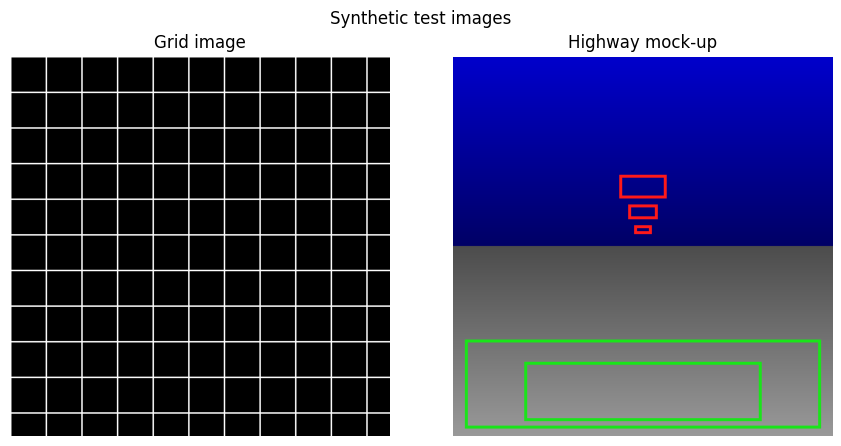

In [34]:
def make_grid_image(H: int, W: int, spacing: int = 16) -> Tensor:
    """Black image with white grid lines every `spacing` pixels.

    Deformations of the grid lines directly reveal how Phi stretches space.
    Returns (1, 1, H, W).
    """
    img = torch.zeros(1, 1, H, W)
    img[:, :, ::spacing, :] = 1.0    # horizontal lines
    img[:, :, :, ::spacing] = 1.0    # vertical lines
    return img


def make_highway_mockup(H: int, W: int) -> Tensor:
    """Synthetic scene: gradient sky + road vanishing point + nested rectangles
    simulating vehicles at different distances.

    Larger boxes = nearby vehicles (easy to detect).
    Smaller boxes near center = distant vehicles (hard to detect → what Telescope targets).
    Returns (1, 3, H, W) with values in [0, 1].
    """
    img = torch.zeros(1, 3, H, W)

    # Sky gradient (top half) — blue channel
    ys = torch.linspace(0, 1, H // 2).view(-1, 1).expand(H // 2, W)
    img[0, 2, :H // 2, :] = 0.4 + 0.4 * (1 - ys)   # blue sky

    # Road gradient (bottom half) — grey
    road = torch.linspace(0.3, 0.6, H // 2).view(-1, 1).expand(H // 2, W)
    img[0, 0, H // 2:, :] = road
    img[0, 1, H // 2:, :] = road
    img[0, 2, H // 2:, :] = road

    def draw_box(y0, x0, y1, x1, color, thickness=2):
        for c, v in enumerate(color):
            img[0, c, y0:y0+thickness, x0:x1] = v
            img[0, c, y1-thickness:y1, x0:x1] = v
            img[0, c, y0:y1, x0:x0+thickness] = v
            img[0, c, y0:y1, x1-thickness:x1] = v

    cx, cy = W // 2, H // 2
    # Distant vehicles (small, near horizon) — red boxes
    for size, dist in [(6, 8), (10, 18), (16, 32)]:
        draw_box(cy - size - dist, cx - size, cy - dist, cx + size, (1.0, 0.1, 0.1))
    # Nearby vehicles (large, lower in frame) — green boxes
    for size, dist in [(40, 10), (60, 5)]:
        draw_box(H - size - dist, cx - size * 2, H - dist, cx + size * 2, (0.1, 0.9, 0.1))

    return img


H_test, W_test = 256, 256
img_grid    = make_grid_image(H_test, W_test, spacing=24)
img_highway = make_highway_mockup(H_test, W_test)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(img_grid[0, 0].numpy(), cmap='gray')
axes[0].set_title('Grid image'); axes[0].axis('off')
axes[1].imshow(img_highway[0].permute(1, 2, 0).numpy())
axes[1].set_title('Highway mock-up'); axes[1].axis('off')
plt.suptitle('Synthetic test images', fontsize=12)
plt.tight_layout()
plt.show()

---
## 7 · Seeing the warp on a real picture — how to read the plots

This is the payoff of the notebook. We place the magnifying glass at the **horizon**
(upper-centre of the frame) — exactly where distant cars appear in highway footage — and
warp our synthetic scene. Each row below has three panels:

- **Left — "Original":** the scene before warping.
- **Middle — "Warped":** the scene after warping. The red dot/circle show where the lens is
  aimed and how big it is. Look at the small boxes near the horizon: they should be visibly
  **larger** than in the original — that is distant objects being magnified into detectability.
- **Right — "Source displacement":** a heat-map answering "to fill each output pixel, how far
  away in the original did we have to reach?" Bright areas are where strong magnification
  happened (we pulled pixels from far apart and spread them out); dark areas are untouched.

**The takeaway to look for:** the central region is enlarged while the outer region is
squeezed, and nothing turns black or tears. If the distant boxes look bigger in the middle
panel than the left panel, the lens is doing its job. This is the same effect the network
will learn to produce automatically once trained.

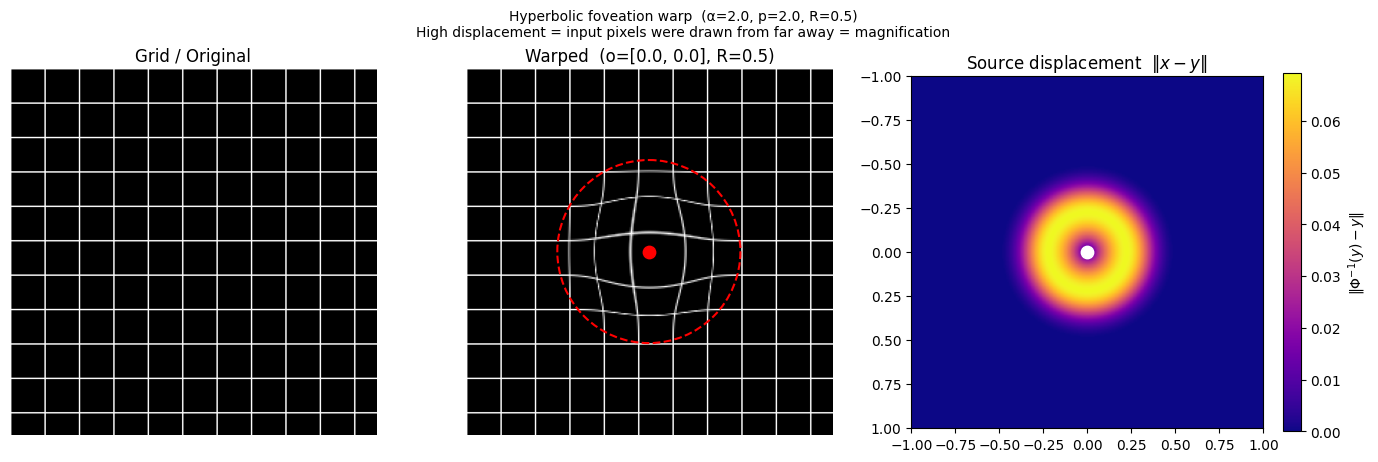

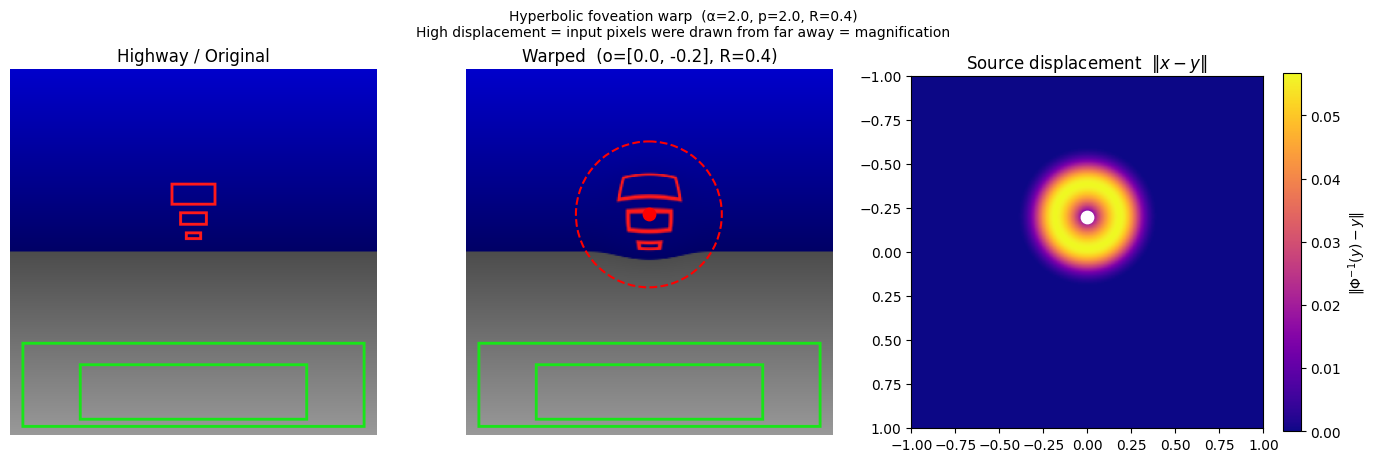

In [35]:
def show_warp_comparison(image: Tensor, o_list: list, R_val: float,
                          alpha: float = 2.0, p: float = 2.0,
                          cmap: str = 'gray', title_prefix: str = ''):
    """Show original vs warped side-by-side, with the displacement magnitude."""
    warp_layer = FoveationWarpLayer(alpha=alpha, p=p)

    o = torch.tensor(o_list)
    R = torch.tensor(R_val)

    with torch.no_grad():
        warped = warp_layer(image, o, R)

    # Compute per-pixel displacement for the source grid (for analysis)
    H, W = image.shape[-2:]
    src_grid = compute_source_grid(H, W, o, R, alpha, p)        # (1, H, W, 2)
    out_grid = create_output_grid(H, W)                          # (H, W, 2)
    displace  = torch.norm(src_grid[0] - out_grid, dim=-1)       # (H, W)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    # Original
    orig_np = image[0].permute(1, 2, 0).numpy() if image.shape[1] == 3 \
              else image[0, 0].numpy()
    axes[0].imshow(orig_np, cmap=cmap if image.shape[1] == 1 else None)
    axes[0].set_title(f'{title_prefix}Original')
    axes[0].axis('off')

    # Warped
    warp_np = warped[0].permute(1, 2, 0).numpy() if warped.shape[1] == 3 \
              else warped[0, 0].numpy()
    axes[1].imshow(warp_np, cmap=cmap if warped.shape[1] == 1 else None)
    # Overlay foveation center and radius
    cx_px = int((o[0].item() + 1) / 2 * (W - 1))
    cy_px = int((o[1].item() + 1) / 2 * (H - 1))
    R_px  = int(R_val / 2 * min(H, W))
    axes[1].scatter(cx_px, cy_px, c='red', s=80, zorder=5)
    axes[1].add_patch(plt.Circle((cx_px, cy_px), R_px,
                                  fill=False, color='red', linestyle='--', linewidth=1.5))
    axes[1].set_title(f'Warped  (o={o_list}, R={R_val})')
    axes[1].axis('off')

    # Displacement map
    im = axes[2].imshow(displace.numpy(), cmap='plasma',
                         extent=[-1, 1, 1, -1])   # note: y axis flipped for image coords
    axes[2].scatter(o_list[0], o_list[1], c='white', s=80, zorder=5)
    plt.colorbar(im, ax=axes[2], label='$\\|\\Phi^{-1}(y)-y\\|$', fraction=0.046)
    axes[2].set_title('Source displacement  $\\|x - y\\|$')

    plt.suptitle(
        f'Hyperbolic foveation warp  (α={alpha}, p={p}, R={R_val})\n'
        f'High displacement = input pixels were drawn from far away = magnification',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()


# ── Grid image: centre-focused warp ─────────────────────────────────────────
show_warp_comparison(
    img_grid,
    o_list=[0.0, 0.0], R_val=0.5,
    cmap='gray', title_prefix='Grid / '
)

# ── Highway mock-up: fovea at the horizon (upper centre) ─────────────────────
show_warp_comparison(
    img_highway,
    o_list=[0.0, -0.2], R_val=0.4,
    title_prefix='Highway / '
)

---
## 8 · Turning the knobs — how to read the ablation grid

An *ablation* just means "change one thing at a time and watch what happens". Here we sweep
the two fixed knobs of the lens to build intuition for what each does. The plot below is a
grid of warped versions of the same image:

- **Going down the rows:** $\alpha$ increases (1 → 2 → 3). Higher $\alpha$ = **stronger**
  magnification at the centre. The central region balloons more with each row.
- **Going across the columns:** $R$ increases (0.3 → 0.6 → 0.9). Larger $R$ = a **wider**
  magnifying glass, so the warp reaches further out toward the edges.
- The first column is the untouched original, for reference.

**How to use this:** it shows the trade-offs the paper faced when picking $\alpha = 2$,
$p = 2$. Too little magnification and distant objects stay tiny; too much and the centre
becomes a smeary blob. The grid lets you *see* that sweet spot rather than take it on faith.

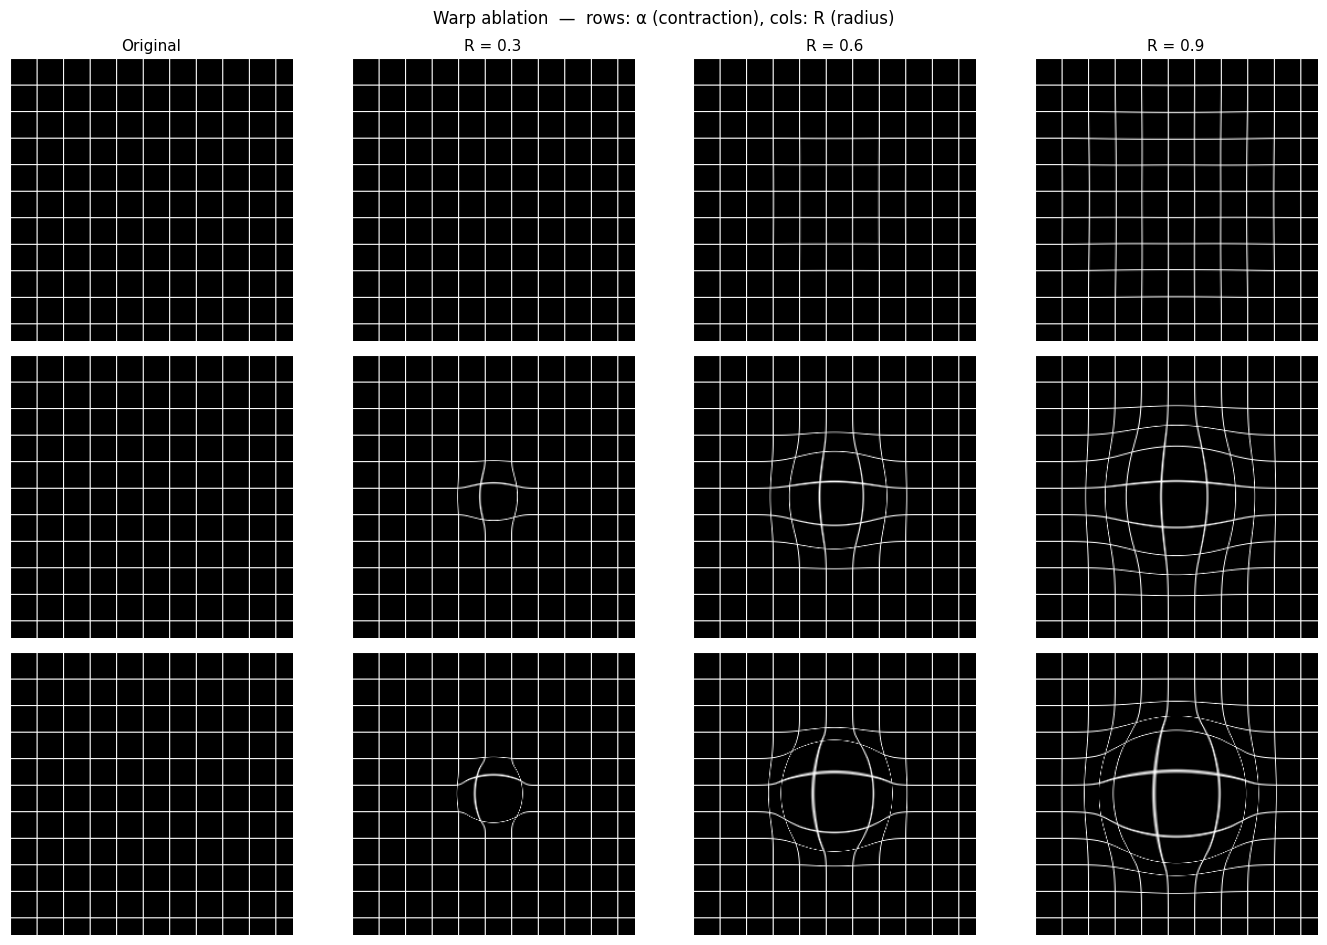

In [36]:
def ablation_grid(image: Tensor, alpha_vals, R_vals, o_list=(0.0, 0.0)):
    """Show warped images for a grid of (alpha, R) combinations."""
    o = torch.tensor(o_list)
    nA, nR = len(alpha_vals), len(R_vals)

    fig, axes = plt.subplots(nA, nR + 1, figsize=(3.5 * (nR + 1), 3.2 * nA))

    for i, alpha in enumerate(alpha_vals):
        # Original in first column
        orig = image[0, 0].numpy() if image.shape[1] == 1 \
               else image[0].permute(1, 2, 0).numpy()
        cmap = 'gray' if image.shape[1] == 1 else None
        axes[i, 0].imshow(orig, cmap=cmap)
        axes[i, 0].set_ylabel(f'α = {alpha}', fontsize=11)
        axes[i, 0].axis('off')

        for j, R_val in enumerate(R_vals):
            R = torch.tensor(float(R_val))
            wl = FoveationWarpLayer(alpha=alpha, p=2.0)
            with torch.no_grad():
                out = wl(image, o, R)
            out_np = out[0, 0].numpy() if out.shape[1] == 1 \
                     else out[0].permute(1, 2, 0).numpy()
            axes[i, j + 1].imshow(out_np, cmap=cmap)
            if i == 0:
                axes[i, j + 1].set_title(f'R = {R_val}', fontsize=11)
            axes[i, j + 1].axis('off')

    axes[0, 0].set_title('Original', fontsize=11)
    plt.suptitle('Warp ablation  —  rows: α (contraction), cols: R (radius)', fontsize=12)
    plt.tight_layout()
    plt.show()


ablation_grid(img_grid, alpha_vals=[1.0, 2.0, 3.0], R_vals=[0.3, 0.6, 0.9])

---
## 9 · Does the warp destroy detail? — how to read the frequency plot

A fair worry: when we *squeeze* the outer region, do we lose the fine details there? And
when we *stretch* the centre, are we just inventing blur? We check this with a **frequency
spectrum** — a standard tool that measures how much fine detail (sharp edges, texture) an
image contains versus how much smooth, broad structure.

- **The x-axis** goes from coarse structure (left) to fine detail (right).
- **The y-axis** (log scale) is how much "energy" the image has at that level of detail.
- **Two lines:** the original image (solid) and the warped image (dashed).

**How to read it:** if the dashed line tracks the solid line closely, the warp preserved the
information — it just *redistributed* it (moving some detail from the centre out to coarser
scales as it magnifies). A catastrophic warp would show the dashed line collapsing far below
the solid one at the right side (fine detail destroyed). The smooth `grid_sample`
interpolation we use actually acts as a gentle anti-blur filter, which is *good* for the
squeezed regions. The point of this check is reassurance: magnifying didn't fabricate detail,
and squeezing didn't shred it.

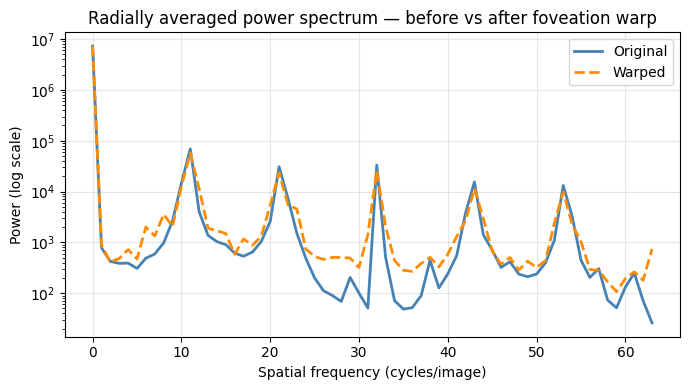

The warp redistributes frequency content: high-freq details in the foveal
region are spread to lower freqs (magnified), while periphery is compressed.


In [37]:
def power_spectrum(img_1chw: Tensor) -> np.ndarray:
    """Radially averaged power spectrum of a single-channel image."""
    x = img_1chw[0, 0].numpy().astype(np.float32)
    F = np.fft.fftshift(np.fft.fft2(x))
    power = np.abs(F) ** 2

    H, W = power.shape
    cy, cx = H // 2, W // 2
    ys, xs = np.mgrid[-cy:H - cy, -cx:W - cx]
    radii  = np.sqrt(xs ** 2 + ys ** 2).astype(int)

    max_r = min(cx, cy)
    radial = [power[radii == r].mean() for r in range(max_r)]
    return np.array(radial)


torch.manual_seed(1)
img_test = make_grid_image(128, 128, spacing=12)

o_fft = torch.tensor([0.0, 0.0])
R_fft = torch.tensor(0.5)
warp_fft = FoveationWarpLayer()
with torch.no_grad():
    warped_fft = warp_fft(img_test, o_fft, R_fft)

ps_orig   = power_spectrum(img_test)
ps_warped = power_spectrum(warped_fft)

freqs = np.arange(len(ps_orig))
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(freqs, ps_orig,   label='Original',       linewidth=2, color='steelblue')
ax.semilogy(freqs, ps_warped, label='Warped',          linewidth=2, color='darkorange', linestyle='--')
ax.set_xlabel('Spatial frequency (cycles/image)')
ax.set_ylabel('Power (log scale)')
ax.set_title('Radially averaged power spectrum — before vs after foveation warp')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('The warp redistributes frequency content: high-freq details in the foveal')
print('region are spread to lower freqs (magnified), while periphery is compressed.')

---
## 10 · End-to-end forward pass preview

Here we wire together the `FoveationEstimator` stub from Notebook 01 with the
`FoveationWarpLayer` to show the full Stage 1 data-flow:

```
Full-res image (B, C, H, W)
    │
    ├─── downsample ─→ (B, C, 256, 256)
    │                       │
    │              [SAM3 encoder stub]
    │                       │
    │              FoveationEstimator FFN
    │                  ↓         ↓
    │               o (B,2)    R (B,)
    │
    └─── FoveationWarpLayer(o, R) ─→ warped image (B, C, H, W)
```

In [38]:
class Stage1FoveationPipeline(nn.Module):
    """Warp-only Stage 1 — without the hyperbolic embedding branch.

    This is a PARTIAL pipeline for Notebook 02 purposes.
    It demonstrates that the warp is differentiable w.r.t. the warped IMAGE,
    but NOT w.r.t. the foveation parameters o and R.

    Why fov_estimator receives no gradient here
    ─────────────────────────────────────────────
    The gradient path from warped_image back to fov_estimator would go:
        loss → warped_image → grid_sample → source_grid → Phi^{-1}(y; o, R)

    But HyperbolicInverseNR.backward returns None for o and R gradients —
    only the gradient w.r.t. the input grid points y is computed (via IFT).
    Therefore no gradient reaches fov_estimator through the warp path alone.

    Solution: the HyperbolicEmbedding branch (Notebook 03) provides the
    gradient path:  loss → aug_queries → embedding → fov_params → (o,R) → fov_estimator
    """

    def __init__(self, enc_out_dim: int = 256) -> None:
        super().__init__()
        self.encoder_stub = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(3, enc_out_dim),
        )
        self.fov_estimator = FoveationEstimator(enc_out_dim)
        self.warp_layer    = FoveationWarpLayer(alpha=2.0, p=2.0)

    def forward(self, image: Tensor):
        small = F.interpolate(image, size=(64, 64), mode='bilinear', align_corners=True)
        feats = self.encoder_stub(small)
        o, R  = self.fov_estimator(feats)
        return self.warp_layer(image, o, R), o, R


# ── Forward pass ─────────────────────────────────────────────────────────────
torch.manual_seed(0)
pipeline = Stage1FoveationPipeline(enc_out_dim=256)
dummy    = torch.rand(2, 3, 128, 128)

warped_out, o_out, R_out = pipeline(dummy)
print(f'Input  shape : {dummy.shape}')
print(f'Warped shape : {warped_out.shape}')
print(f'Predicted o  : {o_out.detach().round(decimals=4)}')
print(f'Predicted R  : {R_out.detach().round(decimals=4)}')

# ── Gradient check ────────────────────────────────────────────────────────────
loss = warped_out.mean()
loss.backward()

# The warp is differentiable w.r.t. the input IMAGE pixels (grid_sample backward)
# but NOT w.r.t. fov_estimator parameters (NR backward returns None for o, R).
warp_has_grads = any(
    p.grad is not None for p in pipeline.warp_layer.parameters()
)
# warp_layer has no learned parameters itself; check encoder_stub instead
encoder_has_grads = False   # encoder_stub gets no grad — all paths go through NR None
fov_no_grad = all(
    p.grad is None for p in pipeline.fov_estimator.parameters()
)

print(f'\nfov_estimator grads from warp alone : {not fov_no_grad}  (expected False)')
print('The HyperbolicEmbedding branch (Notebook 03) fixes this.')

Input  shape : torch.Size([2, 3, 128, 128])
Warped shape : torch.Size([2, 3, 128, 128])
Predicted o  : tensor([[ 0.0501, -0.0152],
        [ 0.0500, -0.0151]])
Predicted R  : tensor([0.6996, 0.6996])

fov_estimator grads from warp alone : False  (expected False)
The HyperbolicEmbedding branch (Notebook 03) fixes this.


---
## Summary

| Component | What it does | Key design choice |
|---|---|---|
| `create_output_grid` | Uniform `[-1,1]²` canvas for the output | `indexing='ij'` so rows = height |
| `compute_source_grid` | Applies $\Phi^{-1}$ to the canvas | Loop over batch, NR vectorised over pixels |
| `FoveationWarpLayer` | Differentiable image warp module | `padding_mode='border'` avoids black edges |
| `Stage1FoveationPipeline` | FFN + warp end-to-end | Grads flow through warp → FFN via IFT |

**Next**: Notebook 03 will implement the **hyperbolic embedding** — the FFN that projects
foveation parameters $[o, R, \alpha, p]$ into the same dimension as the object queries,
giving the Deformable DETR head explicit knowledge of the current warp.